# 15 - CNN VGG16 scratch mejorada con augmentation y TTA

Experimento CNN sin transfer learning basado en el `10_vgg16_scratch`, que fue el mejor resultado de la rama CNN scratch hasta ese punto. Se diferencia porque anade augmentations pensadas para imagen aerea, `AdamW`, `label_smoothing`, mayor paciencia de entrenamiento y TTA en Codabench.


## Librerias y configuracion


In [4]:
import json
import time
import zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

RUN_START = time.perf_counter()

print('GPUs disponibles:', tf.config.list_physical_devices('GPU'))


GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [5]:
SEED = 42
BATCH_SIZE = 32
EPOCHS = 80
VALIDATION_SIZE = 0.15
IMAGE_SHAPE = (224, 224, 3)

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
LABEL_SMOOTHING = 0.05

np.random.seed(SEED)
tf.random.set_seed(SEED)


## Datos


### Localizacion de inputs


In [6]:
KAGGLE_INPUT_DIR = Path('/kaggle/input')
WORKDIR = Path('/kaggle/working')

if not KAGGLE_INPUT_DIR.exists():
    raise FileNotFoundError('No existe /kaggle/input. Ejecuta este notebook en Kaggle.')

array_matches = sorted(KAGGLE_INPUT_DIR.rglob('X_all.npy'))
working_candidate = WORKDIR / 'xview_arrays' / 'X_all.npy'
if working_candidate.exists():
    array_matches = [working_candidate] + array_matches

if not array_matches:
    available_inputs = [p.name for p in KAGGLE_INPUT_DIR.iterdir() if p.is_dir()]
    raise FileNotFoundError(
        'No se encontro X_all.npy. Anade el dataset xview_arrays creado con 00_1. '
        f'Inputs disponibles: {available_inputs}'
    )

ARRAYS_ROOT = array_matches[0].parent

json_matches = sorted(KAGGLE_INPUT_DIR.rglob('xview_ann_train.json'))
if not json_matches:
    available_inputs = [p.name for p in KAGGLE_INPUT_DIR.iterdir() if p.is_dir()]
    raise FileNotFoundError(
        'No se encontro xview_ann_train.json. Anade tambien el dataset original xview_recognition. '
        f'Inputs disponibles: {available_inputs}'
    )

ANN_JSON = json_matches[0]
DATA_ROOT = ANN_JSON.parent
TRAIN_DIR = DATA_ROOT / 'xview_train'
TEST_DIR = DATA_ROOT / 'xview_test'

print('ARRAYS_ROOT:', ARRAYS_ROOT)
print('DATA_ROOT:', DATA_ROOT)
print('ANN_JSON:', ANN_JSON)
print('TRAIN_DIR exists:', TRAIN_DIR.exists())
print('TEST_DIR exists:', TEST_DIR.exists())


ARRAYS_ROOT: /kaggle/input/datasets/eduardocama/xview-array/xview_arrays
DATA_ROOT: /kaggle/input/datasets/eduardocama/xview-recognition1/xview_recognition
ANN_JSON: /kaggle/input/datasets/eduardocama/xview-recognition1/xview_recognition/xview_ann_train.json
TRAIN_DIR exists: True
TEST_DIR exists: True


### Lectura de arrays


In [7]:
DATA_LOAD_START = time.perf_counter()

X_all = np.load(ARRAYS_ROOT / 'X_all.npy')
y_all_idx = np.load(ARRAYS_ROOT / 'y_all_idx.npy')
filenames = np.load(ARRAYS_ROOT / 'filenames.npy')
image_ids = np.load(ARRAYS_ROOT / 'image_ids.npy')
category_names = np.load(ARRAYS_ROOT / 'category_names.npy').astype(str).tolist()
num_classes = len(category_names)

print('X_all:', X_all.shape, X_all.dtype, 'RAM aprox:', X_all.nbytes / 1024**3, 'GB')
print('y_all_idx:', y_all_idx.shape, y_all_idx.dtype)
print('filenames:', filenames.shape)
print('image_ids:', image_ids.shape)
print('num_classes:', num_classes)
print(category_names)


X_all: (18746, 224, 224, 3) uint8 RAM aprox: 2.6280040740966797 GB
y_all_idx: (18746,) int32
filenames: (18746,)
image_ids: (18746,)
num_classes: 13
['Cargo plane', 'Small car', 'Bus', 'Truck', 'Motorboat', 'Fishing vessel', 'Dump truck', 'Excavator', 'Building', 'Helipad', 'Storage tank', 'Shipping container', 'Pylon']


### Comprobacion de una imagen


Filename: xview_train/Building/0234476c-a017-4c9b-bd2f-872193076cca.tif
Image id: 0234476c-a017-4c9b-bd2f-872193076cca.tif
Shape: (224, 224, 3)
Dtype: uint8
Min / Max: 0 86
Etiqueta: Building
Primeros pixeles del array original:
[[[45 30 19]
  [45 30 19]
  [46 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]]
Primeros pixeles normalizados:
[[[0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]
  [0.18039216 0.11764706 0.07450981]]

 [[0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]]

 [[0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]]]


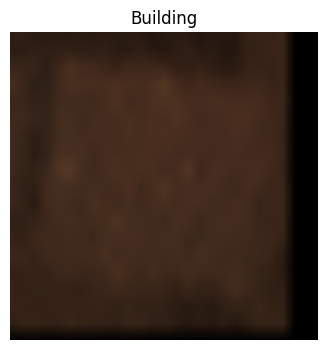

In [8]:
sample_idx = 0
sample_img = X_all[sample_idx]
sample_label_idx = int(y_all_idx[sample_idx])

print('Filename:', filenames[sample_idx])
print('Image id:', image_ids[sample_idx])
print('Shape:', sample_img.shape)
print('Dtype:', sample_img.dtype)
print('Min / Max:', sample_img.min(), sample_img.max())
print('Etiqueta:', category_names[sample_label_idx])
print('Primeros pixeles del array original:')
print(sample_img[:3, :3, :])
print('Primeros pixeles normalizados:')
print((sample_img.astype(np.float32) / 255.0)[:3, :3, :])

plt.figure(figsize=(4, 4))
plt.imshow(sample_img)
plt.title(category_names[sample_label_idx])
plt.axis('off')
plt.show()


### Split train/valid


In [9]:
indices = np.arange(len(X_all))
train_idx, val_idx = train_test_split(
    indices,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    shuffle=True,
    stratify=y_all_idx,
)

X_train = X_all[train_idx]
X_valid = X_all[val_idx]
y_train_idx = y_all_idx[train_idx]
y_valid_idx = y_all_idx[val_idx]

y_train = tf.keras.utils.to_categorical(y_train_idx, num_classes=num_classes).astype(np.float32)
y_valid = tf.keras.utils.to_categorical(y_valid_idx, num_classes=num_classes).astype(np.float32)

DATA_LOAD_TIME = time.perf_counter() - DATA_LOAD_START

print('X_train:', X_train.shape, X_train.dtype, 'RAM aprox:', X_train.nbytes / 1024**3, 'GB')
print('X_valid:', X_valid.shape, X_valid.dtype, 'RAM aprox:', X_valid.nbytes / 1024**3, 'GB')
print('y_train:', y_train.shape, y_train.dtype)
print('y_valid:', y_valid.shape, y_valid.dtype)
print(f'Tiempo carga arrays/split: {DATA_LOAD_TIME:.2f} s')


X_train: (15934, 224, 224, 3) uint8 RAM aprox: 2.2337894439697266 GB
X_valid: (2812, 224, 224, 3) uint8 RAM aprox: 0.3942146301269531 GB
y_train: (15934, 13) float32
y_valid: (2812, 13) float32
Tiempo carga arrays/split: 23.44 s


## Red


### Augmentation


In [10]:
class RandomRotate90(tf.keras.layers.Layer):
    def call(self, inputs, training=None):
        if training:
            k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
            return tf.image.rot90(inputs, k=k)
        return inputs


data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    RandomRotate90(),
    tf.keras.layers.RandomRotation(0.05, fill_mode='reflect'),
    tf.keras.layers.RandomZoom(height_factor=0.08, width_factor=0.08, fill_mode='reflect'),
    tf.keras.layers.RandomTranslation(height_factor=0.05, width_factor=0.05, fill_mode='reflect'),
    tf.keras.layers.RandomContrast(0.10),
], name='data_augmentation')


I0000 00:00:1780590527.235768      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780590527.241706      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


### VGG16 scratch mejorada


In [11]:
inputs = tf.keras.Input(shape=IMAGE_SHAPE)
x = tf.keras.layers.Rescaling(1.0 / 255.0)(inputs)
x = data_aug(x)

base = tf.keras.applications.VGG16(
    include_top=False,
    weights=None,
    input_tensor=x,
)

x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.45)(x)
x = tf.keras.layers.Dense(512, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.45)(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.30)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name='vgg16_scratch_aug_tta')

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy'],
)

model.summary()


Model: "vgg16_scratch_aug_tta"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             

 Total params: 15,116,109 (57.66 MB)

 Trainable params: 15,114,061 (57.66 MB)

 Non-trainable params: 2,048 (8.00 KB)

### Callbacks


In [12]:
MODEL_PATH = WORKDIR / '15_vgg16_scratch_aug_tta.weights.h5'

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        str(MODEL_PATH),
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=5,
        min_lr=1e-7,
        verbose=1,
    ),
    tf.keras.callbacks.TerminateOnNaN(),
]

print('Modelo guardado en:', MODEL_PATH)


Modelo guardado en: /kaggle/working/15_vgg16_scratch_aug_tta.weights.h5


### Entrenamiento


In [13]:
TRAIN_START = time.perf_counter()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

TRAIN_TIME = time.perf_counter() - TRAIN_START

best_idx = int(np.argmax(history.history['val_accuracy']))
best_value = float(np.max(history.history['val_accuracy']))
print('Best validation model: epoch', best_idx + 1, '- val_accuracy', best_value)
print(f'Tiempo entrenamiento: {TRAIN_TIME:.2f} s')


Epoch 1/80


I0000 00:00:1780590542.618624     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


498/498 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.1856 - loss: 2.4110
Epoch 1: val_accuracy improved from None to 0.09637, saving model to /kaggle/working/15_vgg16_scratch_aug_tta.weights.h5

Epoch 1: finished saving model to /kaggle/working/15_vgg16_scratch_aug_tta.weights.h5
498/498 ━━━━━━━━━━━━━━━━━━━━ 272s 507ms/step - accuracy: 0.2414 - loss: 2.2863 - val_accuracy: 0.0964 - val_loss: 2.4069 - learning_rate: 1.0000e-04
Epoch 2/80
498/498 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.3143 - loss: 2.0719
Epoch 2: val_accuracy did not improve from 0.09637
498/498 ━━━━━━━━━━━━━━━━━━━━ 245s 491ms/step - accuracy: 0.3238 - loss: 2.0377 - val_accuracy: 0.0459 - val_loss: 6.3881 - learning_rate: 1.0000e-04
Epoch 3/80
498/498 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.3526 - loss: 1.9550
Epoch 3: val_accuracy improved from 0.09637 to 0.22475, saving model to /kaggle/working/15_vgg16_scratch_aug_tta.weights.h5

Epoch 3: finished saving model to /kaggle/working/15_vgg16_scratc

## Resultados


### Graficas


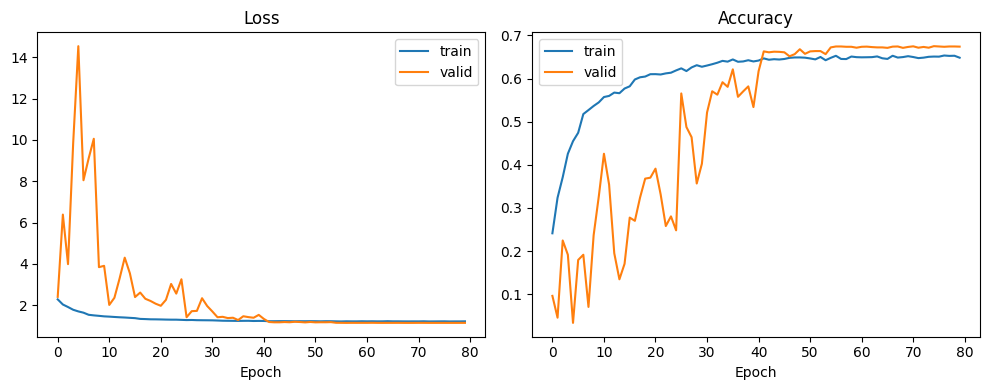

In [14]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='valid')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='valid')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()


### Predicciones de validacion


In [15]:
model.load_weights(MODEL_PATH)

valid_loss, valid_accuracy = model.evaluate(X_valid, y_valid, batch_size=BATCH_SIZE, verbose=1)
print('Validation loss:', valid_loss)
print('Validation accuracy:', valid_accuracy)

probs = model.predict(X_valid, batch_size=BATCH_SIZE, verbose=1)
y_pred_idx = np.argmax(probs, axis=1)
y_true_idx = y_valid_idx


88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step - accuracy: 0.6750 - loss: 1.1493
Validation loss: 1.1493010520935059
Validation accuracy: 0.674964427947998
88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 144ms/step


### Matriz de confusion


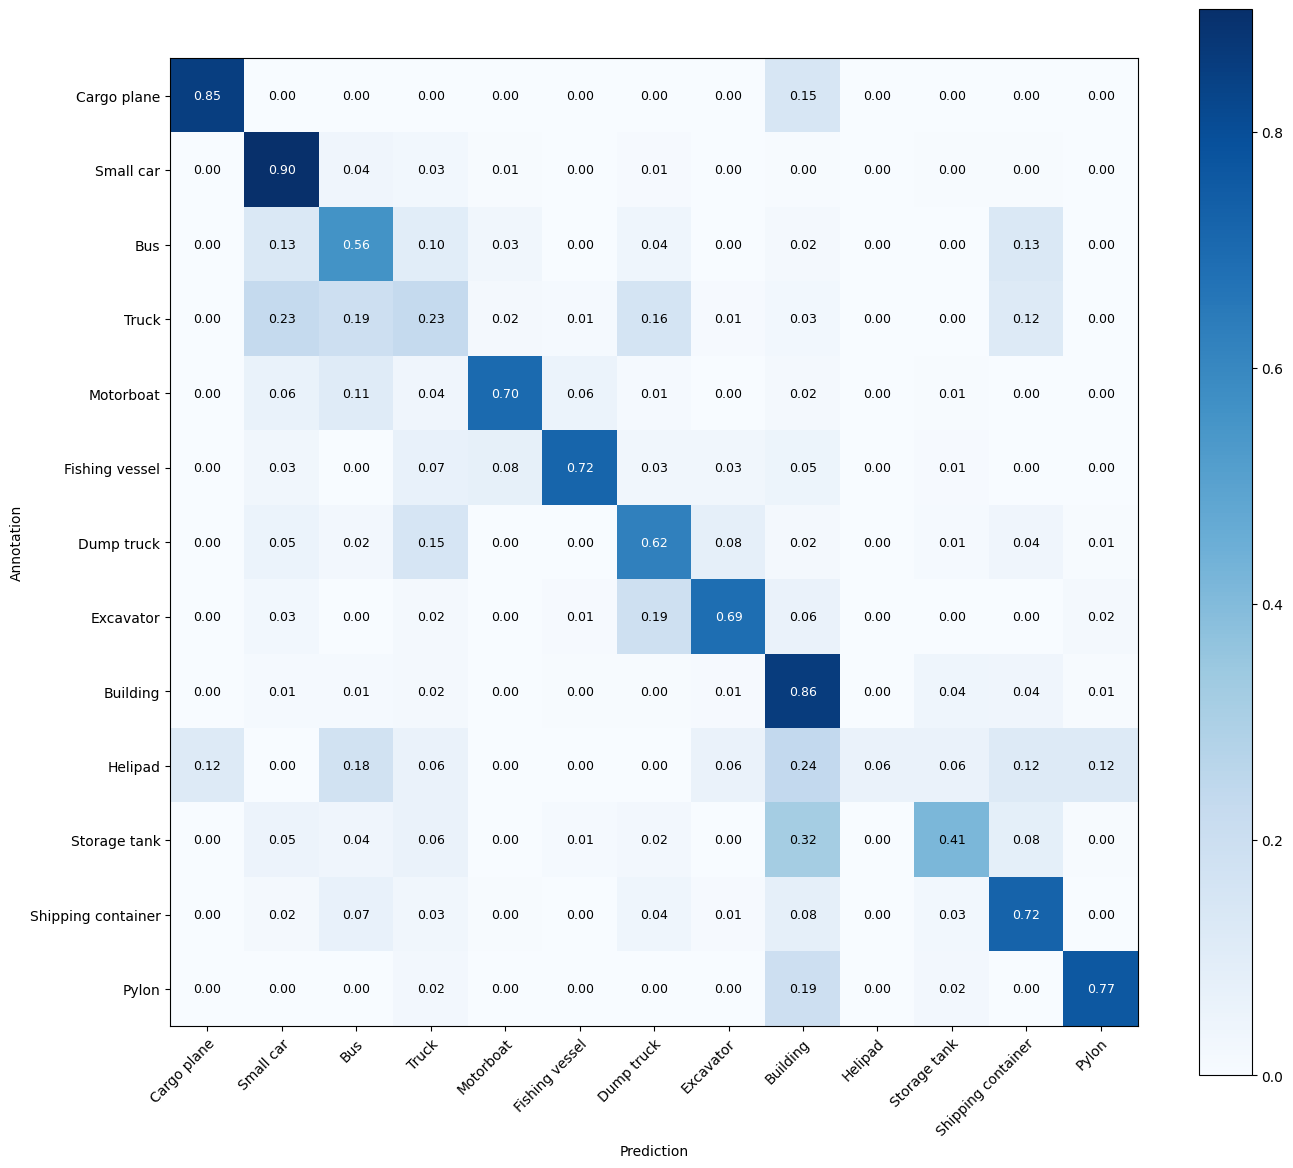

In [16]:
cm = confusion_matrix(y_true_idx, y_pred_idx, labels=list(range(num_classes)))

def draw_confusion_matrix_percent(cm, labels):
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), np.finfo(np.float64).eps)

    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(cm_norm, interpolation='nearest', cmap=plt.colormaps['Blues'], vmin=0.0, vmax=max(0.01, cm_norm.max()))
    fig.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        ylabel='Annotation',
        xlabel='Prediction',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    threshold = cm_norm.max() / 2.0
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            value = cm_norm[i, j]
            ax.text(
                j,
                i,
                f'{value:.2f}',
                ha='center',
                va='center',
                color='white' if value > threshold else 'black',
                fontsize=9,
            )

    fig.tight_layout()
    plt.show()
    return cm_norm

cm_norm = draw_confusion_matrix_percent(cm, category_names)


### Metricas


In [17]:
print(classification_report(y_true_idx, y_pred_idx, target_names=category_names, digits=4))


                    precision    recall  f1-score   support

       Cargo plane     0.9759    0.8526    0.9101        95
         Small car     0.7418    0.9038    0.8148       499
               Bus     0.5193    0.5585    0.5382       265
             Truck     0.4000    0.2289    0.2912       332
         Motorboat     0.8058    0.7000    0.7492       160
    Fishing vessel     0.7917    0.7170    0.7525       106
        Dump truck     0.5066    0.6216    0.5583       185
         Excavator     0.7364    0.6864    0.7105       118
          Building     0.7582    0.8609    0.8063       539
           Helipad     1.0000    0.0588    0.1111        17
      Storage tank     0.7165    0.4136    0.5245       220
Shipping container     0.5764    0.7249    0.6422       229
             Pylon     0.7826    0.7660    0.7742        47

          accuracy                         0.6750      2812
         macro avg     0.7162    0.6225    0.6295      2812
      weighted avg     0.6681    0.675

## Codabench


### TTA


In [18]:
def tta_batches(images):
    return [
        np.ascontiguousarray(images),
        np.ascontiguousarray(np.flip(images, axis=2)),
        np.ascontiguousarray(np.flip(images, axis=1)),
        np.ascontiguousarray(np.rot90(images, k=1, axes=(1, 2))),
        np.ascontiguousarray(np.rot90(images, k=2, axes=(1, 2))),
        np.ascontiguousarray(np.rot90(images, k=3, axes=(1, 2))),
    ]


def predict_with_tta(model, images, batch_size=64):
    probs_sum = None
    variants = tta_batches(images)

    for variant in variants:
        probs = model.predict(variant, batch_size=batch_size, verbose=0)
        probs_sum = probs if probs_sum is None else probs_sum + probs

    return probs_sum / len(variants)


### Generacion del submission


In [19]:
CODABENCH_START = time.perf_counter()

def load_test_image(filename):
    return np.array(Image.open(DATA_ROOT / filename).convert('RGB'))

test_files = sorted(TEST_DIR.rglob('*.tif'))
print('Number of testing images:', len(test_files))
assert len(test_files) > 0, 'No se encontraron imagenes .tif en TEST_DIR.'

model.load_weights(MODEL_PATH)
predictions_data = {'images': {}, 'annotations': {}}
batch_size = 64

for start in range(0, len(test_files), batch_size):
    batch_paths = test_files[start:start + batch_size]
    json_filenames = [path.relative_to(TEST_DIR).as_posix() for path in batch_paths]
    load_filenames = [path.relative_to(DATA_ROOT).as_posix() for path in batch_paths]

    images = np.stack([load_test_image(filename) for filename in load_filenames]).astype(np.uint8)
    probs = predict_with_tta(model, images, batch_size=batch_size)
    pred_idx = np.argmax(probs, axis=1)
    pred_scores = np.max(probs, axis=1)

    for offset, (path, json_filename, cls_idx, score) in enumerate(zip(batch_paths, json_filenames, pred_idx, pred_scores)):
        idx = start + offset
        predictions_data['images'][idx] = {
            'image_id': path.name,
            'filename': json_filename,
            'width': 224,
            'height': 224,
        }
        predictions_data['annotations'][idx] = {
            'image_id': path.name,
            'category_id': category_names[int(cls_idx)],
            'score': float(score),
            'bbox': [0, 0, 224, 224],
        }

    print(f'Procesadas {min(start + batch_size, len(test_files))}/{len(test_files)}')

assert len(predictions_data['images']) == len(test_files)
assert len(predictions_data['annotations']) == len(test_files)

prediction_path = WORKDIR / 'prediction_15.json'
submission_path = WORKDIR / 'submission_15.zip'

with open(prediction_path, 'w', encoding='utf-8') as outfile:
    json.dump(predictions_data, outfile)

with zipfile.ZipFile(submission_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(prediction_path, arcname='prediction.json')

CODABENCH_TIME = time.perf_counter() - CODABENCH_START

print('Archivos generados:')
print(prediction_path, '-', prediction_path.stat().st_size, 'bytes')
print(submission_path, '-', submission_path.stat().st_size, 'bytes')
print(f'Tiempo Codabench: {CODABENCH_TIME:.2f} s')

from IPython.display import FileLink, display
display(FileLink(str(submission_path)))


Number of testing images: 2365
Procesadas 64/2365
Procesadas 128/2365
Procesadas 192/2365
Procesadas 256/2365
Procesadas 320/2365
Procesadas 384/2365
Procesadas 448/2365
Procesadas 512/2365
Procesadas 576/2365
Procesadas 640/2365
Procesadas 704/2365
Procesadas 768/2365
Procesadas 832/2365
Procesadas 896/2365
Procesadas 960/2365
Procesadas 1024/2365
Procesadas 1088/2365
Procesadas 1152/2365
Procesadas 1216/2365
Procesadas 1280/2365
Procesadas 1344/2365
Procesadas 1408/2365
Procesadas 1472/2365
Procesadas 1536/2365
Procesadas 1600/2365
Procesadas 1664/2365
Procesadas 1728/2365
Procesadas 1792/2365
Procesadas 1856/2365
Procesadas 1920/2365
Procesadas 1984/2365
Procesadas 2048/2365
Procesadas 2112/2365
Procesadas 2176/2365
Procesadas 2240/2365
Procesadas 2304/2365
Procesadas 2365/2365
Archivos generados:
/kaggle/working/prediction_15.json - 706847 bytes
/kaggle/working/submission_15.zip - 162529 bytes
Tiempo Codabench: 118.66 s


/kaggle/working/submission_15.zip

### Resumen de tiempos


In [20]:
TOTAL_TIME = time.perf_counter() - RUN_START
print('Resumen de tiempos')
if 'DATA_LOAD_TIME' in globals():
    print(f'- Carga/preparacion de datos: {DATA_LOAD_TIME:.2f} s')
if 'TRAIN_TIME' in globals():
    print(f'- Entrenamiento: {TRAIN_TIME:.2f} s')
if 'CODABENCH_TIME' in globals():
    print(f'- Codabench con TTA: {CODABENCH_TIME:.2f} s')
print(f'- Tiempo total Run All: {TOTAL_TIME:.2f} s')
print(f'- Tiempo total Run All: {TOTAL_TIME / 60:.2f} min')


Resumen de tiempos
- Carga/preparacion de datos: 23.44 s
- Entrenamiento: 19605.00 s
- Codabench con TTA: 118.66 s
- Tiempo total Run All: 19782.91 s
- Tiempo total Run All: 329.72 min
